## Formatting for Plots
### (IGNORE THIS IF YOU ARE A GENERAL USER)

In [1]:
import sys
import pandas as pd
from pathlib import Path
root = Path().resolve()
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from analysislib import formatting
formatting.format_notebook()

from analysislib import sdss
sdss.setup(pd.read_csv("data/SDSS_500k_v4.csv"))
df = sdss._galaxies()

---

## Part 2 — Colour Bimodality

---

<div style="width: 1200px">

In the last part, we met the SDSS data that we're going to analyse, and covered some of the most important fundamentals. In this chapter, we'll explore the question:

<center>
<span style="
border: 2px solid #DDDDDD;
padding: 10px;
font-size: 25px;
font-style: italic;">
"What colour are galaxies?"</span>
</center>

<br>

This is a deceptively simple question, but the answer turns out to be pretty surprising!

</div>

---

### What Does Galaxy Colour Actually Mean?

---

<div style="width: 700px;
            display: inline-block;
            margin-right: 50px">

So it turns out that a galaxy's colour isn't random, and it tells us quite a bit about the galaxy's **stellar population**, meaning which kinds of stars live inside it, and whether new stars are still being born.

Stars come in a range of temperatures, and temperature determines colour:

* **Hot, massive stars** burn bright blue-white. They are young and  consume their fuel so rapidly that they live fast and die young. So, a galaxy full of these stars would appear **blue**. However, these galaxies come in multiple different sub-types, like blue compact dwarf galaxies (BCDs) or faint blue galaxies (FBGs). Each sub-class has different properties, for example BCDs are often less than 800 million years old (super young compared to most galaxyes), small and irregular, and usually contain large amounts of gas and not many heavier elements like metals. This is because in order to produce heavy metals, stars must explode in an event called a **supernova**, which is very unlikely if the star has just been formed.

* On the other hand, **cool, low-mass stars** glow dimly in red and orange. They are much older than their blue counterparts and burn their fuel so slowly that they can outlive many generations of their hotter cousins. A galaxy dominated by these stars looks **red**. Compared to blue galaxies, red ones are comprised of stars that are over 10 billion years old (for comparison, our sun is only about 4 billion years old), and have much heavier elements. In these galaxies, stars have already consumed a lot of hydrogen and helium, and red supergiants that have exploded as supernovae create heavy elements like gold, uranium and lead.

</div>

<div style="width: 450px;
            display: inline-block">
<img src="images/star_age.png"></img>
<center>
<i>Credit: Haylam Yuen</i>
</center>
</div>

<br><br>


<div style="width: 1200px">

<center>
<img width=480px src="images/ngc4449.jpg"></img>
<img width=550px src="images/big_wheel.jpg"></img>

<i><b>LEFT</b>: NGC 4449 (A young galaxy with actively forming stars). Credit: Wikipedia</i>
<br>
<i><b>RIGHT</b>: Big Wheel Galaxy (An older galaxy that has largely stopped forming stars). Credit: NASA</i>
</center>

</div>

<br>

<div style="width: 1200px">

So a galaxy's colour is really a measure of **how recently it has been forming stars**. Blue galaxies are actively building new stars right now. Red galaxies have largely stopped.

In the SDSS dataset, we measure colour using the difference between two photometric bands:

$$g - r = \text{(brightness in green band)} - \text{(brightness in red band)}$$

A **low** $g - r$ value means the galaxy is brighter in green/blue light, so it's a blue, star-forming galaxy. A **high** $g - r$ value means it's brighter in red light, so it's a red, older galaxy.

</div>

---

### The Two Peaks

---

<div style="width: 1200px">

Now you might expect that if galaxies are continuously forming stars at different rates - some very actively, some less so, some barely at all - then their colours should form a smooth, continuous spread from blue to red.

But it turns out that this is **not what we see**.

When astronomers first plotted the colour distribution of large galaxy samples in the early 2000s, they found that galaxies cluster into **two distinct peaks** separated by a surprising gap. There are lots of blue galaxies, lots of red galaxies, and relatively few in between.

This is **really interesting**!

Let's see this in our own data.

</div>

---

### Setting Up

---

Okay, so let's start by importing some libraries. This will let us use some commonly used algorithms without having to code everything from scratch:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import ipywidgets as widgets

<div style="width: 1200px">

Then, let's reapply all the code cleaning we did in Part 1, and add a new column which we will call `g_r`, which represents the difference between the object's brighness in the two bands.

</div>

In [3]:
galaxies = sdss._galaxies() # Load data (re-apply the cleaning from Part 1)
galaxies["g_r"] = galaxies["g"] - galaxies["r"] # Compute g-r colour index

print(f"Working with {len(galaxies):,} galaxies") # Print the number of galaxies in the dataset after loading and cleaning

Working with 261,793 galaxies


---

### Plotting the "Two Peaks"

---

<div style="
display: inline-block;
width: 800px;
margin-right: 70px">

Okay, now lets plot these galaxies, with bluer galaxies on the left, and redder galaxies on the right, with the height of the graph indicating the number of galaxies that fall into that colour category.

I warn you, there's quite a bit of code that is used to generate this plot, but most of it is pretty simple. Essentially, we look at the different possible ranges that `g_r` could be. For example, it might be between 0.25 and 0.26, or between 0.26 and 0.27.

Then, we count how many galaxies fall into each range, and make a **histogram** out of all the categories (the grey rectangles), where each rectangle is a category, and the height of the rectangle is representative of how many galaxies fall into that range.

Lastly, we'll use a fancy algorithm called **Gaussian KDE** (kernel density estimation) to make a smooth curve which roughly traces out the histogram. This algorithm works in a really cool way. It basically adds up lots of little bumps to estimate the histogram, and you can change the size of the bumps (**bandwidth factor**) to decide if you want the curve to be more jaggedy but more precise, or smooth and less precise.

</div>

<div style="
display: inline-block;
width: 330px">
<img src="images/kde.png"></img>
<center><i>Credit: Anonymous [Stack Overflow]</i></center>
</div>

In this plot, you can change the bandwidth factor using the slider (it may take a few seconds for the new plot to load).

In [4]:
def bimodality_1(bandwidth):
       # Setup the plot so that it has the right size and a nice dark background
       fig, ax = plt.subplots(figsize=(18, 6), facecolor="#1e1e1e") # Create a figure and axis for plotting, with a dark background colour
       ax.set_facecolor("#1e1e1e")
       g_r = galaxies["g_r"].values # Extract the g-r colour index value
       x_range = np.linspace(-0.2, 1.4, 1000) # Create a range of x-values for the plot

       # Setup algorithm
       kde = gaussian_kde(g_r, bw_method=bandwidth) # Initialise the Gaussian KDE
       kde_vals = kde(x_range) # Evaluate the KDE on the x_range
       kde_vals /= kde_vals.max()  # Normalise to 1 for clean y-axis

       # Create the histogram
       hist_counts, hist_edges = np.histogram(g_r, bins=100, range=(-0.2, 1.4), density=True) # Make the histogram have 100 "bins" (categories)
       hist_counts = hist_counts / hist_counts.max()
       ax.bar(hist_edges[:-1], hist_counts, width=np.diff(hist_edges),color="#aaaaaa", alpha=0.10, align="edge", zorder=1) # Plot the histogram as a bar chart

       # Green Valley shading
       gv_lo, gv_hi = 0.55, 0.75 # Define the boundaries of the green valley region
       gv_mask = (x_range >= gv_lo) & (x_range <= gv_hi) # Create a mask for the green valley region
       ax.fill_between(x_range, 0, kde_vals / kde_vals.max(), where=gv_mask, color="#69db7c", alpha=0.18, zorder=1) # Plot the green valley shading using the mask

       # Blue cloud shading
       blue_mask = x_range < gv_lo # Create a mask for the blue cloud region
       ax.fill_between(x_range, 0, kde_vals, where=blue_mask, color="#74c7ec", alpha=0.20, zorder=1) # Plot the blue cloud shading using the mask

       # Red sequence shading
       red_mask = x_range > gv_hi # Create a mask for the red sequence region
       ax.fill_between(x_range, 0, kde_vals, where=red_mask, color="#f38ba8", alpha=0.20, zorder=1) # Plot the red sequence shading using the mask

       # Plot the Gaussian KDE line
       ax.plot(x_range, kde_vals, lw=2.5, color="#e0e0e0", zorder=2)

       # Final plot formatting
       ax.set_xlim(-0.2, 1.4)
       ax.set_ylim(0, 1.25)
       ax.set_yticks([])
       ax.set_xlabel("g − r colour index", color="#aaaaaa", fontsize=10)
       ax.set_ylabel("Relative number of galaxies", color="#aaaaaa", fontsize=10)
       ax.set_title("Galaxy Colour Distribution Plot", color="#e0e0e0", fontsize=14, loc="left", pad=12)
       ax.tick_params(colors="#777777", labelsize=8)
       ax.grid(True, linestyle=":", alpha=0.12, color="#ffffff")
       for spine in ax.spines.values(): spine.set_edgecolor("#333333")

       plt.tight_layout()
       plt.show()

# Make the slider and interactive output
bandwidth_slider = widgets.FloatSlider(value=0.1, min=0.02, max=0.8, step=0.02, description="Bandwidth Factor =", continuous_update=False, 
                                       layout=widgets.Layout(width="90%"), style={"description_width": "initial"})
out = widgets.interactive_output(bimodality_1, {"bandwidth": bandwidth_slider})
display(widgets.VBox([bandwidth_slider], layout=widgets.Layout(padding="2px 0")), out)

Output()

<div style="
display: inline-block;
width: 650px;
margin-right: 50px">

Hmm... this is interesting!

In theory we should be getting 2 distinct peaks - one on the blue side, and one on the red side. Instead, there seems to be few blue galaxies, and a whole heap of red ones, with weird behaviour on the far right. This is usually an indicator that there is something fundamentally wrong, or skewed about the data that we are using.

It turns out that the reason it looks like this is because of 2 main things. Firstly, the weird bahaviour on the right is probably because of something called **right-censorship**. Essentially, the `g-r` measurements are artificially capped at some number. The result of this is that every measurement that exceeds that number will be put in the same category. Then, when the KDE algorithm tries to fit the histogram, it sees a spike on the right side, and tries to account for that by making the curve go back up, resulting in the weird behaviour that we can see.

</div>

<div style="
width: 500px;
display: inline-block">

<img src="images/stellar_magnitudes.gif"></img>

<center>
<i>Credit: Ram Chandra Gotame</i>
</center>

</div>

<div style="width: 1200px">

Additionally, the lack of the blue galaxy peak is due to the fact that the SDSS had some intrinsic bias towards red galaxies because of something called **Malmquist bias**. This bias says that brighness-limited surveys like the SDSS over-represent luminous objects, since those are the only ones visible at large distances.

Now you may be thinking to yourself "*What? But I thought that blue stars were brighter, so shouldn't blue stars be over-represented?*"

Well... yes and no. Blue stars *are* intrinsically brighter, but the galaxies that contain them usually have a dimmer **apparent brightness**. We will talk about the difference between absolute and apparent brightness in-depth later on, but basically blue galaxies are actually bright, however they appear faint in telescopes because they are often smaller and have more spead-out stars.

</div>

---

### Plotting the "Two Peaks" (Attempt #2)

---

<div style="width: 1200px">

So, let's try to make the dataset a bit more fair by restricting ourselves to only look at nearby galaxies. This, in theory, will allow the galaxies to be evenly surveyed, since even dim galaxies will be detected because they are so close. To implement this in our code, we will only select galaxies with a redshift below 0.1:

</div>

In [5]:
galaxies_plot = galaxies[galaxies["redshift"] < 0.1].copy() # Filter to z < 0.1
galaxies_plot["g_r"] = galaxies_plot["g"] - galaxies_plot["r"] # Compute g-r colour index for the filtered dataset

# Further filter to remove g-r outliers
galaxies_plot = galaxies_plot[
    (galaxies_plot["g_r"] > -0.2) & (galaxies_plot["g_r"] < 1.4)
]

print(f"Low-z sample: {len(galaxies_plot):,} galaxies (z < 0.1)") # Print the number of galaxies in the low-redshift sample after filtering

Low-z sample: 45,510 galaxies (z < 0.1)


Then, we'll do the exact same plotting as last time:

In [6]:
def bimodality_2(bandwidth):
    # Setup the plot so that it has the right size and a nice dark background
    fig, ax = plt.subplots(figsize=(18, 6), facecolor="#1e1e1e") # Create a figure and axis for plotting, with a dark background colour
    ax.set_facecolor("#1e1e1e")
    g_r = galaxies_plot["g_r"].values # Extract the g-r colour index value
    x_range = np.linspace(-0.2, 1.4, 1000) # Create a range of x-values for the plot

    # Setup algorithm
    kde = gaussian_kde(g_r, bw_method=bandwidth) # Initialise the Gaussian KDE
    kde_vals = kde(x_range) # Evaluate the KDE on the x_range
    kde_vals /= kde_vals.max()  # Normalise to 1 for clean y-axis

    # Create the histogram
    hist_counts, hist_edges = np.histogram(g_r, bins=100, range=(-0.2, 1.4), density=True) # Make the histogram have 100 "bins" (categories)
    hist_counts = hist_counts / hist_counts.max()
    ax.bar(hist_edges[:-1], hist_counts, width=np.diff(hist_edges),color="#aaaaaa", alpha=0.10, align="edge", zorder=1) # Plot the histogram as a bar chart

    # Green Valley shading
    gv_lo, gv_hi = 0.55, 0.75 # Define the boundaries of the green valley region
    gv_mask = (x_range >= gv_lo) & (x_range <= gv_hi) # Create a mask for the green valley region
    ax.fill_between(x_range, 0, kde_vals / kde_vals.max(), where=gv_mask, color="#69db7c", alpha=0.18, zorder=1) # Plot the green valley shading using the mask

    # Blue cloud shading
    blue_mask = x_range < gv_lo # Create a mask for the blue cloud region
    ax.fill_between(x_range, 0, kde_vals, where=blue_mask, color="#74c7ec", alpha=0.20, zorder=1) # Plot the blue cloud shading using the mask

    # Red sequence shading
    red_mask = x_range > gv_hi # Create a mask for the red sequence region
    ax.fill_between(x_range, 0, kde_vals, where=red_mask, color="#f38ba8", alpha=0.20, zorder=1) # Plot the red sequence shading using the mask

    # Plot the Gaussian KDE line
    ax.plot(x_range, kde_vals, lw=2.5, color="#e0e0e0", zorder=3)

    # Find the peaks in the KDE
    blue_peak = x_range[np.argmax(kde_vals * (x_range < gv_lo))]
    red_peak  = x_range[np.argmax(kde_vals * (x_range > gv_hi))]

    # Annotate the peaks and the green valley
    ax.annotate("Blue Cloud", xy=(blue_peak, kde([blue_peak])[0] / kde(x_range).max()), xytext=(blue_peak - 0.20, 0.75), # Position the annotation text to the left of the blue peak
        color="#74c7ec", fontsize=9, fontweight="bold", ha="center", arrowprops=dict(arrowstyle="-|>", color="#74c7ec", lw=1.2))
    ax.annotate("Red Sequence", xy=(red_peak, kde([red_peak])[0] / kde(x_range).max()), xytext=(red_peak + 0.22, 0.75), # Position the annotation text to the right of the red peak
        color="#f38ba8", fontsize=9, fontweight="bold", ha="center", arrowprops=dict(arrowstyle="-|>", color="#f38ba8", lw=1.2))
    ax.text(0.645, 0.10, "Green\nValley", color="#69db7c", fontsize=8, # Position the "Green Valley" text in the middle of the green valley region
            fontweight="bold", ha="center", va="bottom", style="italic")

    # Final plot formatting
    ax.set_xlim(-0.2, 1.4)
    ax.set_ylim(0, 1.25)
    ax.set_yticks([])
    ax.set_xlabel("g − r colour index", color="#aaaaaa", fontsize=10)
    ax.set_ylabel("Relative number of galaxies", color="#aaaaaa", fontsize=10)
    ax.set_title("Galaxy Colour Distribution Plot", color="#e0e0e0", fontsize=14, loc="left", pad=12)
    ax.tick_params(colors="#777777", labelsize=8)
    ax.grid(True, linestyle=":", alpha=0.12, color="#ffffff")
    for spine in ax.spines.values(): spine.set_edgecolor("#333333")

    plt.tight_layout()
    plt.show()

# Make the slider and interactive output
bandwidth_slider = widgets.FloatSlider(value=0.2, min=0.02, max=0.8, step=0.02, description="Bandwidth Factor =", continuous_update=False, 
                                       layout=widgets.Layout(width="90%"), style={"description_width": "initial"})
out = widgets.interactive_output(bimodality_2, {"bandwidth": bandwidth_slider})
display(widgets.VBox([bandwidth_slider], layout=widgets.Layout(padding="2px 0")), out)

Output()

<div style="width: 1200px">

Okay, this is much better. We've eliminated the weird behaviour on the far right of the plot, and we can sort of see a plateau on the blue side, before the measurements go back up into the red peak. However, we still can't properly see the blue cloud peak.

It turns out that the reason this is still not right is because of the nature of the `g` and `r` measurements. As you could probably guess, red galaxies are the brightest in the `r` band, and since we are using the `r` band for our calculations, red galaxies are definitely counted. On the other hand, bluer galaxies are the brightest in a blue band. However, the SDSS doesn't take photos in the blue band, so we have to resort to using the green (`g`) band, which doesn't detect blue galaxies as well. As a result, red galaxies are detected much more than blue galaxies, when in reality there are actually lots of blue galaxies.

</div>

---

### Plotting the "Two Peaks" (Attempt #3)

---

<div style="width: 1200px">

Unfortunately, we can't just get measurements from a blue band. However, since this is still a brightness issue, we can just set the maximum redshift to be even smaller. In our case, $z < 0.045$ should work:

</div>

In [7]:
galaxies_plot_2 = galaxies[galaxies["redshift"] < 0.045].copy() # Filter to z < 0.045
galaxies_plot_2["g_r"] = galaxies_plot_2["g"] - galaxies_plot_2["r"] # Compute g-r colour index for the filtered dataset

# Further filter to remove g-r outliers
galaxies_plot_2 = galaxies_plot_2[
    (galaxies_plot_2["g_r"] > -0.2) & (galaxies_plot_2["g_r"] < 1.4)
]

print(f"Low-z sample: {len(galaxies_plot_2):,} galaxies (z < 0.045)") # Print the number of galaxies in the low-redshift sample after filtering

Low-z sample: 9,154 galaxies (z < 0.045)


Then we just plot the graph as normal:

In [8]:
def bimodality_3(bandwidth):
    # Setup the plot so that it has the right size and a nice dark background
    fig, ax = plt.subplots(figsize=(18, 6), facecolor="#1e1e1e") # Create a figure and axis for plotting, with a dark background colour
    ax.set_facecolor("#1e1e1e")
    g_r = galaxies_plot_2["g_r"].values # Extract the g-r colour index value
    x_range = np.linspace(-0.2, 1.4, 1000) # Create a range of x-values for the plot

    # Setup algorithm
    kde = gaussian_kde(g_r, bw_method=bandwidth) # Initialise the Gaussian KDE
    kde_vals = kde(x_range) # Evaluate the KDE on the x_range
    kde_vals /= kde_vals.max()  # Normalise to 1 for clean y-axis

    # Create the histogram
    hist_counts, hist_edges = np.histogram(g_r, bins=100, range=(-0.2, 1.4), density=True) # Make the histogram have 100 "bins" (categories)
    hist_counts = hist_counts / hist_counts.max()
    ax.bar(hist_edges[:-1], hist_counts, width=np.diff(hist_edges),color="#aaaaaa", alpha=0.10, align="edge", zorder=1) # Plot the histogram as a bar chart

    # Find the peaks in the KDE
    peaks, _ = find_peaks(kde_vals, height=0.15, distance=60)
    blue_x = x_range[peaks[0]]  if len(peaks) >= 2 else 0.40 # Position of the blue peak (or a default value if not found)
    red_x  = x_range[peaks[-1]] if len(peaks) >= 1 else 0.91 # Position of the red peak (or a default value if not found)
    blue_h = kde([blue_x])[0] / kde(x_range).max() # Height of the blue peak for annotation
    red_h  = kde([red_x])[0]  / kde(x_range).max() # Height of the red peak for annotation
    gv_mid = (blue_x + red_x) / 2 # Midpoint between the blue and red peaks for green valley annotation
    gv_lo  = blue_x + (red_x - blue_x) * 0.35 # Lower boundary of the green valley, set at 35% of the way from blue to red
    gv_hi  = blue_x + (red_x - blue_x) * 0.65 # Upper boundary of the green valley, set at 65% of the way from blue to red

    # Shading regions
    blue_mask = x_range <= gv_lo # Create a mask for the blue cloud region
    gv_mask   = (x_range >= gv_lo) & (x_range <= gv_hi) # Create a mask for the green valley region
    red_mask  = x_range >= gv_hi # Create a mask for the red sequence region
    ax.fill_between(x_range, 0, kde_vals, where=blue_mask, color="#74c7ec", alpha=0.25, zorder=2) # Plot the blue cloud shading using the mask
    ax.fill_between(x_range, 0, kde_vals, where=gv_mask,   color="#69db7c", alpha=0.25, zorder=2) # Plot the green valley shading using the mask
    ax.fill_between(x_range, 0, kde_vals, where=red_mask,  color="#f38ba8", alpha=0.25, zorder=2) # Plot the red sequence shading using the mask

    # Plot the Gaussian KDE line
    ax.plot(x_range, kde_vals, lw=2.5, color="#e0e0e0", zorder=3)

    # Annotate the peaks and the green valley
    ax.annotate("Blue Cloud\n(active star formation)", xy=(blue_x, blue_h), xytext=(blue_x - 0.20, blue_h + 0.28), # Position the annotation text to the left of the blue peak
        color="#74c7ec", fontsize=9, fontweight="bold", ha="center", arrowprops=dict(arrowstyle="-|>", color="#74c7ec", lw=1.2))
    ax.annotate("Red Sequence\n(quenched, no new stars)", xy=(red_x, red_h), xytext=(red_x + 0.22, red_h - 0.25), # Position the annotation text to the right of the red peak
        color="#f38ba8", fontsize=9, fontweight="bold", ha="center", arrowprops=dict(arrowstyle="-|>", color="#f38ba8", lw=1.2))
    ax.text(gv_mid, 0.10, "Green\nValley", color="#69db7c", fontsize=8, # Position the "Green Valley" text in the middle of the green valley region
            fontweight="bold", ha="center", va="bottom", style="italic")

    # Final plot formatting
    ax.set_xlim(-0.2, 1.4)
    ax.set_ylim(0, 1.25)
    ax.set_yticks([])
    ax.set_xlabel("g − r colour index", color="#aaaaaa", fontsize=10)
    ax.set_ylabel("Relative number of galaxies", color="#aaaaaa", fontsize=10)
    ax.set_title("Galaxy Colour Distribution Plot", color="#e0e0e0", fontsize=14, loc="left", pad=12)
    ax.tick_params(colors="#777777", labelsize=8)
    ax.grid(True, linestyle=":", alpha=0.12, color="#ffffff")
    for spine in ax.spines.values(): spine.set_edgecolor("#333333")

    plt.tight_layout()
    plt.show()

# Make the slider and interactive output
bandwidth_slider = widgets.FloatSlider(value=0.16, min=0.02, max=0.8, step=0.02, description="Bandwidth Factor =", continuous_update=False, 
                                       layout=widgets.Layout(width="90%"), style={"description_width": "initial"})
out = widgets.interactive_output(bimodality_3, {"bandwidth": bandwidth_slider})
display(widgets.VBox([bandwidth_slider], layout=widgets.Layout(padding="2px 0")), out)

Output()

<div style="width: 1200px">

Awesome!!

We can now very clearly see the two peaks of galaxies, one which is called the "blue cloud", and one which is called the "red sequence", however there aren't that many galaxies in-between (Which is exactly what we expected to see)!

I think that, before we continue onwards to ask why there are even 2 peaks, it's helpful to step back and appreciate the process that we just did. We started off with some weird data which didn't match our expectations. Then, we underwent an iterative process to figure out why the data behaved like that, and adjusted our analysis accordingly. This process of trying something, diagnosing why it fails, and refining the approach, is what real data analysis looks like, and its exactly what astronomers and scientists do all the time.

The fact that it was hard to see these two peaks (which is called **colour bimodality**) was not because our method was bad, but rather because the data had some intrinsic bias (we talked about this in Part 1). A $z < 0.045$ sample contains fewer than 10,000 galaxies rather than 500,000, but those 10,000 give us a more honest picture of the local galaxy population than the full biased sample would. This is a concept that's pretty important in astronomy: *more data is not always better data*. Knowing which galaxies are in your sample, and why they are there, matters just as much as how many there are.

<br>

Anyway, the next natural question to ask is: ***"Why are there even 2 peaks in the data?"***

</div>

---

### The Concept of Quenching

---

<div style="width: 1200px">

This tells us something profound: galaxy evolution is not a slow, continuous drift from blue to red. Something causes star formation to **switch off abruptly** — transforming a blue galaxy into a red one relatively quickly on cosmic timescales. This process is called **quenching**.

The gap between the two peaks — where we find the small population of galaxies caught mid-transformation — is called the **Green Valley**.

**Quenching** refers to the process by which a galaxy's star formation switches off — often rapidly and (as far as we can tell) permanently.

Astronomers have proposed several mechanisms that could cause this:

* **AGN feedback:** A supermassive black hole at the galaxy's centre becomes active, blasting out enormous jets of energy that heat and expel the cold gas that would otherwise collapse into new stars.

* **Ram-pressure stripping:** As a galaxy moves through the hot gas pervading a galaxy cluster, that gas strips out the galaxy's own cold gas — starving it of raw star-forming material.

* **Strangulation:** The galaxy's supply of fresh cold gas from the surrounding cosmic web is simply cut off — perhaps after a merger — so star formation slowly runs out of fuel and dies.

What's remarkable is that despite decades of study, astronomers still debate which of these mechanisms dominates, and whether the same mechanism operates across all galaxy masses and environments. The bimodal colour distribution we're about to plot is the key observational fact that any successful theory of galaxy evolution must explain.

</div>

---

### Plot 2 — The Colour–Magnitude Diagram

---

<div style="width: 1200px">

The colour distribution alone is striking, but it becomes even more revealing when we plot colour *against brightness*.

The **Colour–Magnitude Diagram (CMD)** places each galaxy on a 2D plane:

* **x-axis:** $r$-band magnitude — a measure of apparent brightness (brighter objects have *lower* magnitude numbers, following astronomical convention)
* **y-axis:** $g - r$ colour

In this diagram, the Blue Cloud and Red Sequence don't just appear as separate blobs — they reveal a deeper pattern: **brighter (more massive) galaxies tend to be redder**. The Red Sequence is not just a population of old galaxies; it's a population of *massive* old galaxies. This links galaxy mass to quenching history in a fundamental way.

</div>

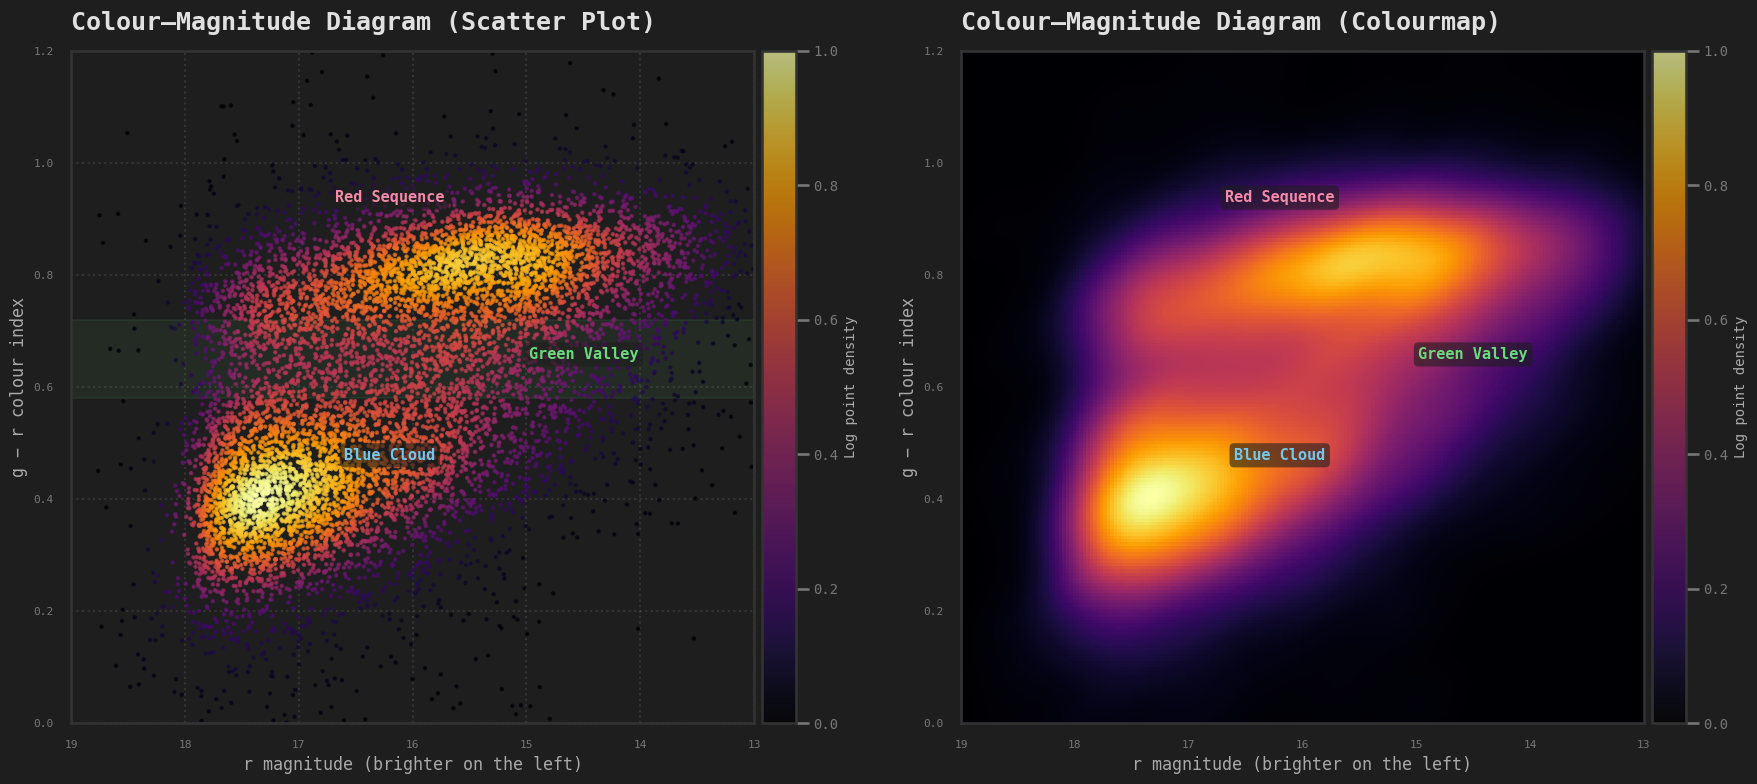

In [10]:
# Define the sample for the colour-magnitude diagram
sample = galaxies_plot_2[(galaxies_plot_2["r"] > 13) & (galaxies_plot_2["r"] < 18.8)].copy()
x = sample["r"].values # r magnitude (brightness)
y = sample["g_r"].values # g-r colour index (bluer = smaller, redder = larger)

# Setup the subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor="#1e1e1e")
axes[0].set_facecolor("#1e1e1e")
axes[1].set_facecolor("#1e1e1e")


# Use Gaussian KDE to figure out the density of points
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy) # Compute the KDE density values
# Use a logarithmic scale for density
log_density = np.log1p(density)
log_density = (log_density - log_density.min()) / (log_density.max() - log_density.min())

# Create the scatter plot
sc = axes[0].scatter(x, y, c=log_density, s=3, alpha=0.7, cmap="inferno")

gv_lo_cmd, gv_hi_cmd = 0.58, 0.72 # Define the green valley boundaries

# Set up the label properties for the annotations
label_properties = dict(fontsize=11, fontweight="bold", ha="center", bbox=dict(boxstyle="round,pad=0.3", fc="#1e1e1e", ec="none", alpha=0.6))

axes[0].axhspan(gv_lo_cmd, gv_hi_cmd, color="#69db7c", alpha=0.07, zorder=0) # Plot the green valley shading using the defined boundaries
axes[0].text(14.5, (gv_lo_cmd + gv_hi_cmd) / 2, "Green Valley", color="#69db7c", **label_properties) # Add green valley text
axes[0].text(16.2, 0.93, "Red Sequence", color="#f38ba8", **label_properties) # Add red sequence text
axes[0].text(16.2, 0.47, "Blue Cloud",   color="#74c7ec", **label_properties) # Add blue cloud text

# Add the colourbar on the side
cbar = plt.colorbar(sc, ax=axes[0], pad=0.01)
cbar.set_label("Log point density", color="#aaaaaa", fontsize=10) # Make the colourbar label
cbar.ax.yaxis.set_tick_params(color="#777777") # Set the colour of the colourbar ticks
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=10) # Set the colour and size of the colourbar tick labels
cbar.outline.set_edgecolor("#333333") # Set the colour of the colourbar outline

# Final formatting
axes[0].set_xlabel("r magnitude (brighter on the left)", color="#aaaaaa", fontsize=12)
axes[0].set_ylabel("g − r colour index", color="#aaaaaa", fontsize=12)
axes[0].set_title("Colour–Magnitude Diagram (Scatter Plot)", color="#e0e0e0", fontsize=18, loc="left", pad=15)
axes[0].set_xlim(19, 13)
axes[0].set_ylim(0, 1.2)
axes[0].tick_params(colors="#777777", labelsize=8)
axes[0].grid(True, linestyle=":", alpha=0.1, color="#ffffff")
for spine in axes[0].spines.values():
        spine.set_edgecolor("#333333")


# Create a pcolourmesh plot
xy = np.vstack([x, y]) # Use Gaussian KDE to figure out the density of points
kde = gaussian_kde(xy)

# Make the Grid
x_grid = np.linspace(19, 13, 200)
y_grid = np.linspace(0, 1.2, 200)
X, Y = np.meshgrid(x_grid, y_grid)

# Add the colourbar on the side
cbar = plt.colorbar(sc, ax=axes[1], pad=0.01)
cbar.set_label("Log point density", color="#aaaaaa", fontsize=10) # Make the colourbar label
cbar.ax.yaxis.set_tick_params(color="#777777") # Set the colour of the colourbar ticks
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=10) # Set the colour and size of the colourbar tick labels
cbar.outline.set_edgecolor("#333333") # Set the colour of the colourbar outline

# Evaluate the density
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kde(positions).reshape(X.shape)
Z_log = np.log1p(Z) # Use a logarithmic scale for density
Z_log = (Z_log - Z_log.min()) / (Z_log.max() - Z_log.min())

# Plot the pcolourmesh
pcm = axes[1].pcolormesh(X, Y, Z_log, cmap="inferno", shading="auto")

axes[1].text(14.5, (gv_lo_cmd + gv_hi_cmd) / 2, "Green Valley", color="#69db7c", **label_properties) # Add green valley text
axes[1].text(16.2, 0.93, "Red Sequence", color="#f38ba8", **label_properties) # Add red sequence text
axes[1].text(16.2, 0.47, "Blue Cloud",   color="#74c7ec", **label_properties) # Add blue cloud text

# Final formatting
axes[1].set_xlabel("r magnitude (brighter on the left)", color="#aaaaaa", fontsize=12)
axes[1].set_ylabel("g − r colour index", color="#aaaaaa", fontsize=12)
axes[1].set_title("Colour–Magnitude Diagram (Colourmap)", color="#e0e0e0", fontsize=18, loc="left", pad=15)

axes[1].set_xlim(19, 13)
axes[1].set_ylim(0, 1.2)
axes[1].tick_params(colors="#777777", labelsize=8)
axes[1].grid(True, linestyle=":", alpha=0.1, color="#ffffff")

for spine in axes[1].spines.values():
    spine.set_edgecolor("#333333")

# Display both plots
plt.tight_layout()
plt.show()

<div style="width: 1200px">

Several things jump out of this diagram:

* The **Red Sequence** is genuinely a *sequence* — it forms a tight, tilted ridge running diagonally. Brighter (more massive) galaxies are slightly redder, and the relationship is surprisingly tight. This regularity suggests that massive galaxies quench early and uniformly, then simply age in place.

* The **Blue Cloud** is much more scattered — star-forming galaxies span a wide range of colours, reflecting the variety of star formation rates and dust contents within them.

* The **Green Valley** (the faint horizontal band) is visibly underpopulated relative to either peak — confirming that the transition between the two populations is swift.

* The colour bar (density) reveals where galaxies pile up. The densest concentrations sit firmly in the Blue Cloud and along the Red Sequence ridge — not in between.

</div>

---

### What We've Learned

---

<div style="width: 1200px">

Two plots, one profound conclusion: galaxy evolution is **bimodal**. Galaxies are not scattered uniformly across all possible colours — they cluster into two distinct families, separated by a sparsely populated transition zone.

This is the observational foundation for everything that follows:

* Something causes star formation to **switch off** — and to do so quickly enough that few galaxies are caught mid-transition
* This process is linked to **galaxy mass**: more massive galaxies are more likely to have quenched
* The Green Valley galaxies are the most scientifically interesting — they are the ones actively undergoing transformation right now

In the next notebook, we move beyond colour and begin examining **size and structure** — asking whether a galaxy's shape and morphology tell the same evolutionary story as its colour.

</div>